NOTES ON GEMINI CREATED CODE     The first thing to do in a notebook is to import dependencies.  This allows the program to access extensive python code libraries that help us to write much shorter code.  
In this case, we are importing the pandas library, which is a powerful tool for dealing with data in tabular form. 
"import pandas as pd" makes this library accessible, and the "as pd" portion allows us to use "pd" as a shortcut to tell the computer to use this library

We load the dataset into a "dataframe" in the command "df = pd.read_csv...."  Pandas has the code needed to read from a csv file and put the data into tabular form.

The "df = " portion is defining this new dataframe as a variable named "df".

It's always a good idea to EXPLORE the data to understand what it contains.  The next two commands set up variables for the number of columns and rows in the table.
Then these values are printed.  

In the command "print(f"Columns: {columns}")", the f" allows us to combine text and the value of the "columns" variable, which is a list of the column names.

The df.info() command produces the table that gives information about the number of entries and their datatype for each column.

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('The_Outbreak_of_1849.csv')

# Get columns and shape
columns = df.columns.tolist()
num_rows = len(df)

print(f"Columns: {columns}")
print(f"Number of rows: {num_rows}")
df.info()

Columns: ['district', 'region', 'population', 'area', 'elevation', 'number_houses', 'house_value_average', 'deaths']
Number of rows: 36
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   district             36 non-null     object
 1   region               36 non-null     object
 2   population           36 non-null     int64 
 3   area                 36 non-null     int64 
 4   elevation            36 non-null     int64 
 5   number_houses        36 non-null     int64 
 6   house_value_average  36 non-null     int64 
 7   deaths               36 non-null     int64 
dtypes: int64(6), object(2)
memory usage: 2.4+ KB


Raw data generally contains missing values.  The data that we are using have been "cleaned" to prevent this.  Nevertheless, it is always a good idea to check for missing values.  Pandas allows us to do this easily with the "df.isnull().sum()" command.  In the code below, we've also managed to get pandas to check for duplicate rows and we've used "df.describe()" to get more information about the data in the numerical columns (datatype int64, which are integers).

In [3]:
# Check for missing values and duplicates
missing_values = df.isnull().sum()
duplicates = df.duplicated().sum()

# Descriptive statistics to check for problematic values (e.g., negative numbers)
summary_stats = df.describe()

print("Missing values per column:")
print(missing_values)
print("\nNumber of duplicate rows:", duplicates)
print("\nSummary Statistics:")
print(summary_stats)

Missing values per column:
district               0
region                 0
population             0
area                   0
elevation              0
number_houses          0
house_value_average    0
deaths                 0
dtype: int64

Number of duplicate rows: 0

Summary Statistics:
          population          area   elevation  number_houses  \
count      36.000000     36.000000   36.000000      36.000000   
mean    65616.000000   2165.666667   41.111111    7406.916667   
std     37878.743873   3543.141318   58.988995    4176.257965   
min     11986.000000    136.000000   -1.000000    1411.000000   
25%     44446.500000    248.750000    7.000000    4645.000000   
50%     54440.500000    724.000000   31.500000    6449.000000   
75%     82367.500000   2766.500000   51.500000    8968.000000   
max    166956.000000  17224.000000  350.000000   17791.000000   

       house_value_average       deaths  
count            36.000000    36.000000  
mean             44.638889   392.333333 

In order to produce plots, we need another dependency.  In the cell below, we are importing the matplotlib.pyplot library as plt so we can call upon it with that 3 letter abbreviation.

Before plotting, we first sorted it so that the plot will show decreasing values.

"df_sorted = " indicates that we are creating a new variable to contain the data, leaving the original unchanged.  This new dataframe contains the data sorted by 'deaths'. Please note that "df.sort_values" tells the computer to sort the dataframe.  The information inside the following parentheses helps to answer the question "How should I sort it?"  We've told it to use the values in the 'deaths' column, and set the boolean value "False" to the ascending argument to ask it to sort them in descending order.

All of the commands that begin with plt. are calling upon the matplotlib plotting library.  In order, the commands: 1) tell the computer to make a bar chart and which columns from which dataframe to use, 2) provide a label for the x-axis, 3) provide a label for the y-axis, 4) provide a title for the chart, 5) provide tickmarks on the x-axis for each value label, and 6) fixes possible spacing issues and prevents the bars from overlapping.

                     district  deaths
13                    Lambeth    1618
16                  Newington     907
22       St. George Southwark     836
20                 Shoreditch     830
1               Bethnal Green     789
0                  Bermondsey     734
7                   Greenwich     718
29     St. Saviour, Southwark     539
35                Whitechapel     506
2                  Camberwell     504
30                    Stepney     501
32                 Wandsworth     484
34                Westminster     437
33                West London     429
17                    Pancras     360
19                Rotherhithe     352
28       St. Olave, Southwark     349
18                     Poplar     313
24                  St. Giles     285
15                 Marylebone     261
3                     Chelsea     247
4              City of London     207
12                 Kensington     206
23     St. George-in-the-East     199
11                  Islington     187
26          

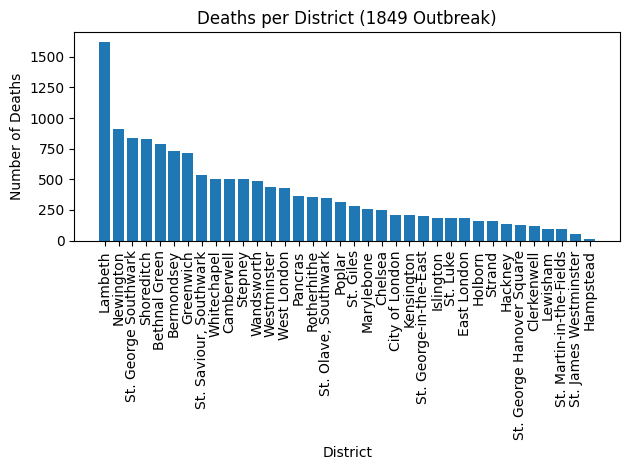

In [4]:
import matplotlib.pyplot as plt

# Sort the data by deaths for better visualization
df_sorted = df.sort_values(by='deaths', ascending=False)

# Create a bar chart
plt.bar(df_sorted['district'], df_sorted['deaths'])
plt.xlabel('District')
plt.ylabel('Number of Deaths')
plt.title('Deaths per District (1849 Outbreak)')
plt.xticks(rotation=90)
plt.tight_layout()

# Save the plot
plt.savefig('deaths_per_district.png')

# Display the sorted data (first few rows to show the trend)
print(df_sorted[['district', 'deaths']])

In the following cell, we are doing some "feature engineering" by calculating values for a new column.  Notice that we are still using the powerful functionality of pandas, without having to use the "pd" abbreviation.  This allows us to perform the calculation for each row to produce the new column "deaths_per_1000".

Other than the sorting and showing the values, the additional commands generated by Gemini are perhaps not necessary.

Gemini has produced a new csv file, and decided to make a whole new dataframe that contains only some of the information to display.

In [5]:
# Calculate deaths per 1000 people
df['deaths_per_1000'] = (df['deaths'] / df['population']) * 1000

# Save the updated dataframe to a new CSV
df.to_csv('The_Outbreak_of_1849_with_deaths_per_1000.csv', index=False)

# Display the districts with the new column, sorted by deaths_per_1000
df_calculated = df[['district', 'population', 'deaths', 'deaths_per_1000']].sort_values(by='deaths_per_1000', ascending=False)
print(df_calculated)

                     district  population  deaths  deaths_per_1000
19                Rotherhithe       17805     352        19.769728
28       St. Olave, Southwark       19375     349        18.012903
22       St. George Southwark       51824     836        16.131522
0                  Bermondsey       48128     734        15.250997
29     St. Saviour, Southwark       35731     539        15.084940
33                West London       28790     429        14.901007
16                  Newington       64816     907        13.993458
13                    Lambeth      139325    1618        11.613135
32                 Wandsworth       50764     484         9.534316
2                  Camberwell       54667     504         9.219456
1               Bethnal Green       90193     789         8.747907
20                 Shoreditch      109257     830         7.596767
7                   Greenwich       99305     718         7.230250
34                Westminster       65609     437         6.66

In the first command in the cell below, we've calculated another column for population density to seek out more information from our data.  

In [6]:
# Calculate population density: population / area
df['population_density'] = df['population'] / df['area']

# Save the updated dataframe to a new CSV
df.to_csv('The_Outbreak_of_1849_with_density.csv', index=False)

# Display the districts with the new column, sorted by population_density
df_density = df[['district', 'population', 'area', 'population_density']].sort_values(by='population_density', ascending=False)
print(df_density)


                     district  population   area  population_density
6                 East London       44406    153          290.235294
31                     Strand       44460    174          255.517241
26                   St. Luke       54055    220          245.704545
10                    Holborn       46621    196          237.862245
25      St. James Westminster       36406    164          221.987805
24                  St. Giles       54214    245          221.281633
33                West London       28790    136          211.691176
5                 Clerkenwell       64778    315          205.644444
23     St. George-in-the-East       48376    243          199.078189
35                Whitechapel       79759    406          196.450739
22       St. George Southwark       51824    282          183.773050
20                 Shoreditch      109257    646          169.128483
29     St. Saviour, Southwark       35731    250          142.924000
4              City of London     

In [7]:
# It can be helpful to look at the first several rows of your dataframe.  Our dataframe is named df.
df.head()


,district,region,population,area,elevation,number_houses,house_value_average,deaths,deaths_per_1000,population_density
0,Bermondsey,South,48128,688,0,5674,18,734,15.250997,69.953488
1,Bethnal Green,East,90193,760,38,11782,9,789,8.747907,118.675000
2,Camberwell,South,54667,4342,4,6843,25,504,9.219456,12.590281
3,Chelsea,West,56538,865,12,5648,29,247,4.368743,65.361850
4,City of London,Central,55932,434,31,7921,117,207,3.700923,128.875576


Gemini generated the code below after being asked to produce scatterplots for specific data.

In the first command of the cell below, Gemini has chosen to import a new plotting library entitled seaborn.  This library is being used to produce the scatterplot and works in conjunction with matplotlib.  

Seaborn is accessed in the command "sns.scatterplot(data=df, x='population_density', y='deaths_per_1000')"

You may have noticed the use of underscores or the lack of spaces.  Variable names and file names cannot include spaces.  Underscores are one way of getting around this.

In [ ]:
import seaborn as sns

# 1. Death Rate vs Population Density
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='population_density', y='deaths_per_1000')
plt.title('Death Rate vs Population Density')
plt.xlabel('Population Density (People per Acre)')
plt.ylabel('Deaths per 1000 People')
plt.savefig('death_rate_vs_density.png')
plt.close()
# Gemini didn't include the command to show the plot before closing it but it is saved
#plt.show()     before closing would show the graph in the output

# 2. Death Rate vs Population
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='population', y='deaths_per_1000')
plt.title('Death Rate vs Total Population')
plt.xlabel('Total Population')
plt.ylabel('Deaths per 1000 People')
plt.savefig('death_rate_vs_population.png')
plt.close()
# Gemini didn't include the command to show the plot before closing it but it is saved


# 3. Death Rate vs Elevation
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='elevation', y='deaths_per_1000')
plt.title('Death Rate vs Elevation')
plt.xlabel('Elevation (Feet)')
plt.ylabel('Deaths per 1000 People')
plt.savefig('death_rate_vs_elevation.png')
plt.close()
# Gemini didn't include the command to show the plot before closing it but it is saved


# Calculate Pearson correlation coefficients
correlations = df[['deaths_per_1000', 'population_density', 'population', 'elevation']].corr()['deaths_per_1000']
print(correlations)

deaths_per_1000       1.000000
population_density   -0.054093
population           -0.278382
elevation            -0.482717
Name: deaths_per_1000, dtype: float64


The correlations above are the Pearson r values for a linear regression.  Values close to 1.0 show a strong positive correlation and values close to -1.0 show a strong negative correlation.  With just the code, we don't get the LLM's ability to provide text to interpret these values.  The LLM by itself is not good at calculating, but it is good at providing predictive text to help make sense of the results.

The code in the cell below was written by Gemini after we asked it to remove the outlier value that was apparent on the elevation scatter plot.  

In the first command, pandas has been used to produce a new dataframe (table) that only contains rows with elevation values of <300. This effectively removed the one row that had this higher elevation.

In the second command, Gemini has written code to simply provide the correlation value between 'deaths_per_1000' and 'elevation' for the filtered data and saved it to a variable (new_correlation).


In [ ]:
# Filter the dataset to remove the outlier (Hampstead has elevation 350)
df_filtered = df[df['elevation'] < 300]

# Calculate the new correlation coefficient for elevation vs deaths_per_1000
new_correlation = df_filtered[['deaths_per_1000', 'elevation']].corr().iloc[0, 1]

# Create a new scatter plot without the outlier
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_filtered, x='elevation', y='deaths_per_1000')
plt.title('Death Rate vs Elevation (Outlier Removed)')
plt.xlabel('Elevation (Feet)')
plt.ylabel('Deaths per 1000 People')
plt.savefig('death_rate_vs_elevation_no_outlier.png')
plt.close()

print(f"New Correlation (Elevation vs Death Rate): {new_correlation}")
# the len(df_filtered) gives the "length" of the filtered dataframe which is the number of rows after removing the outlier.
print(f"Number of rows after removing outlier: {len(df_filtered)}")

New Correlation (Elevation vs Death Rate): -0.7140645738492947
Number of rows after removing outlier: 35


What do you notice?
What do you wonder?